# 7B control-capability trade-off

All values below are illustrative placeholders, not experimental results. Preserve the original single-panel layout for replacement with measured data later.

Run from the repository or `notebooks/`. Saves `figs/steering_tradeoff_7b_toy.pdf` and displays an SVG preview.


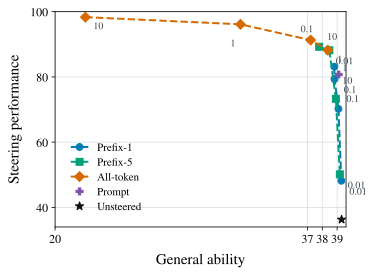

Saved data placeholder figure: /home/xzascc/Documents/code/Prefix/figs/steering_tradeoff_7b_toy.pdf


In [1]:
from pathlib import Path
from io import StringIO
import matplotlib.pyplot as plt
from IPython.display import SVG, display

DATA = [
    # series, strength, general ability, steering performance

    ("Prefix-1", 10,    38.813, 83.127),
    ("Prefix-1", 1,     38.824, 79.341),
    ("Prefix-1", 0.1,   39.087, 70.214),
    ("Prefix-1", 0.01,  39.286, 48.173),

    ("Prefix-5", 10,    37.791, 89.238),
    ("Prefix-5", 1,     38.476, 88.154),
    ("Prefix-5", 0.1,   38.914, 73.286),
    ("Prefix-5", 0.01,  39.183, 50.127),

    ("All-token", 10,   22.042, 98.317),
    ("All-token", 1,    32.487, 96.124),
    ("All-token", 0.1,  37.216, 91.283),
    ("All-token", 0.01, 38.374, 88.195),

    ("Prompt", None,    39.100, 80.733),
    ("Unsteered", None, 39.300, 36.271),
]
STYLES = {
    "Prefix-1":  {"color": "#087DB3", "marker": "o", "linestyle": "--"},
    "Prefix-5":  {"color": "#00A17A", "marker": "s", "linestyle": "--"},
    "All-token": {"color": "#D66A00", "marker": "D", "linestyle": "--"},
    "Prompt":    {"color": "#7953A5", "marker": "P", "linestyle": "None"},
    "Unsteered": {"color": "#111111", "marker": "*", "linestyle": "None"},
}

LABEL_OFFSETS = {
    ("Prefix-1", 10): (8, -17), ("Prefix-1", 1): (8, 8),
    ("Prefix-1", 0.1): (8, 7), ("Prefix-1", 0.01): (8, -14),
    ("Prefix-5", 10): (8, 7), ("Prefix-5", 1): (8, -12),
    ("Prefix-5", 0.1): (8, 6), ("Prefix-5", 0.01): (8, -14),
    ("All-token", 10): (8, -12), ("All-token", 1): (-10, -22),
    ("All-token", 0.1): (-10, 8), ("All-token", 0.01): (8, -14),
}

# Find the repository root whether this cell runs from the repo or notebooks/.
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "notebooks").is_dir() and (p / "figs").is_dir())
OUTPUT = ROOT / "figs" / "steering_tradeoff_7b_toy.pdf"

with plt.rc_context({"font.family": "STIXGeneral", "pdf.fonttype": 42}):
    fig, ax = plt.subplots(figsize=(5.4, 4.0))
    fig.subplots_adjust(left=0.22, right=0.97, bottom=0.22, top=0.97)
    for name, style in STYLES.items():
        points = [row for row in DATA if row[0] == name]
        points.sort(key=lambda row: row[1] or -1, reverse=True)
        ax.plot([row[2] for row in points], [row[3] for row in points],
                color=style["color"], linestyle=style["linestyle"],
                marker=style["marker"], markersize=9 if name == "Unsteered" else 7,
                linewidth=2.0, label=name, zorder=2)
        for series, strength, x, y in points:
            if strength is not None:
                ax.annotate(strength, (x, y),
                            xytext=LABEL_OFFSETS[(series, strength)],
                            textcoords="offset points", fontsize=10, color="#3F4650")

    ax.set(
        xlim=(20.5, 39.6),
        ylim=(34, 100),
        xticks=[20, 37, 38, 39],
        yticks=[40, 60, 80, 100],
    )
    ax.set_xlabel("General ability", fontsize=15, labelpad=7)
    ax.set_ylabel("Steering performance", fontsize=15, labelpad=8)
    ax.grid(color="#D9DDE1", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=12)
    ax.legend(loc="lower left", bbox_to_anchor=(0.02, 0.02), frameon=False,
              fontsize=11, labelspacing=0.35, handlelength=1.6)
    fig.savefig(OUTPUT, format="pdf", bbox_inches="tight")
    preview = StringIO()
    fig.savefig(preview, format="svg", bbox_inches="tight")
    plt.close(fig)
    display(SVG(preview.getvalue()))

print(f"Saved data placeholder figure: {OUTPUT}")
